# Day 1 — Prompt Engineering vs Fine-Tuning

Learn the difference between guiding a model through prompts and teaching it through fine-tuning.

**Key insight:** Prompt engineering works on instruction-tuned models. Base models like GPT-2 cannot follow instructions — they only complete text.

In [1]:
from transformers import pipeline
import matplotlib.pyplot as plt

c:\Users\Nemochan\Desktop\ai-engineering-journey\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---
## Part 1: Base Model vs Instruction-Tuned Model

Compare how a base model (GPT-2) and an instruction-tuned model (Qwen2.5) respond to the same prompt.

In [2]:
prompt = "Explain what is a firewall in simple words."

# GPT-2 (base model)
print("Loading GPT-2 (base model)...")
base = pipeline("text-generation", model="gpt2")

print("\n--- Base Model (GPT-2) ---")
out = base(prompt, max_new_tokens=60, temperature=0.7, do_sample=True, pad_token_id=50256)
print(f"Prompt:   {prompt}")
print(f"Response: {out[0]['generated_text'][len(prompt):].strip()}")

Loading GPT-2 (base model)...


Loading weights: 100%|██████████| 148/148 [00:00<00:00, 2445.72it/s]
[transformers] Passing `generation_config` together with generation-related arguments=({'max_new_tokens', 'pad_token_id', 'do_sample', 'temperature'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=60) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



--- Base Model (GPT-2) ---


[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer GPT2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


Prompt:   Explain what is a firewall in simple words.
Response: Here is a basic example:

1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 2223 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52


In [3]:
# Qwen2.5 (instruction-tuned model)
print("Loading Qwen2.5 (instruction-tuned)...")
chat = pipeline("text-generation", model="Qwen/Qwen2.5-0.5B-Instruct")

print("\n--- Instruction-Tuned Model (Qwen2.5) ---")
msg = [{"role": "user", "content": prompt}]
out = chat(msg, max_new_tokens=80, temperature=0.7)
print(f"Prompt:   {prompt}")
print(f"Response: {out[0]['generated_text'][-1]['content']}")

Loading Qwen2.5 (instruction-tuned)...


Loading weights: 100%|██████████| 290/290 [00:00<00:00, 1681.04it/s]
[transformers] Passing `generation_config` together with generation-related arguments=({'max_new_tokens', 'temperature'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=80) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



--- Instruction-Tuned Model (Qwen2.5) ---


[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer Qwen2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


Prompt:   Explain what is a firewall in simple words.
Response: A firewall is a security system that monitors and controls incoming and outgoing network traffic to ensure that only authorized data is allowed into the network and only authorized users can access it. It acts as an "internet gatekeeper" that allows or blocks specific types of traffic based on predefined rules.

The primary function of a firewall is to prevent unauthorized access to sensitive information and systems by filtering out unwanted traffic from entering the


**Key takeaway:** GPT-2 completes text. Qwen2.5 follows instructions. Prompt engineering only works on instruction-tuned models.

---
## Part 2: Prompt Engineering Techniques

Four common techniques demonstrated on the same instruction-tuned model.

In [4]:
# 1. Zero-Shot — Direct question, no examples
print("1. Zero-Shot Prompting")
msg = [{"role": "user", "content": "What is a firewall?"}]
out = chat(msg, max_new_tokens=80, temperature=0.7)
print(out[0]['generated_text'][-1]['content'])

[transformers] Both `max_new_tokens` (=80) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


1. Zero-Shot Prompting
A firewall is an advanced security system that monitors and controls the flow of data between different networks or systems. It acts as a barrier between internal and external networks, protecting against unauthorized access to sensitive information.

Firewalls typically consist of several components:

1. **Firewall Interface**: This component allows the firewall to communicate with other network devices or systems.

2. **Packet Filtering Engine (PFE)**:


In [5]:
# 2. Few-Shot — Two examples before the question
print("2. Few-Shot Prompting")
msg = [
    {"role": "user", "content": "What is an IP address?"},
    {"role": "assistant", "content": "An IP address is a unique numerical label assigned to each device on a network. It works like a mailing address for your computer."},
    {"role": "user", "content": "What is DNS?"},
    {"role": "assistant", "content": "DNS translates domain names into IP addresses that computers use to locate websites."},
    {"role": "user", "content": "What is a firewall?"}
]
out = chat(msg, max_new_tokens=80, temperature=0.7)
print(out[0]['generated_text'][-1]['content'])

[transformers] Both `max_new_tokens` (=80) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


2. Few-Shot Prompting
A firewall is a security measure used to control the access of data between two or more systems or networks. It monitors traffic and filters it based on predefined rules. The purpose of a firewall is to protect against unauthorized access, blocking malicious traffic while allowing authorized communication. Firewalls can be implemented at various layers of an organization's network, such as the application layer, transport layer, or network layer, depending


In [6]:
# 3. Chain-of-Thought — Explicit reasoning steps
print("3. Chain-of-Thought Prompting")
msg = [{"role": "user", "content": "Explain what a firewall is. Think step by step: first what it protects, then how it filters traffic, then a simple analogy."}]
out = chat(msg, max_new_tokens=120, temperature=0.7)
print(out[0]['generated_text'][-1]['content'])

[transformers] Both `max_new_tokens` (=120) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


3. Chain-of-Thought Prompting
A firewall is a network security system that monitors and controls the flow of data entering or leaving a network. It serves as an external barrier between the internal network (the protected area) and the Internet.

### First, What It Protects:
The primary function of a firewall is to block unauthorized access attempts from outside the protected network to the internal network. This includes both incoming and outgoing traffic from various sources. The protection range can vary depending on the specific application and requirements but typically covers IP addresses within a specified subnet or range.

### How It Filters Traffic:
1. **Rule-Based Filtering**: Firewalls


In [7]:
# 4. Role Prompting — System message sets an expert persona
print("4. Role Prompting (System Message)")
msg = [
    {"role": "system", "content": "You are a cybersecurity professor with 15 years of experience. Explain concepts clearly with real-world analogies for beginners."},
    {"role": "user", "content": "What is a firewall?"}
]
out = chat(msg, max_new_tokens=100, temperature=0.7)
print(out[0]['generated_text'][-1]['content'])

[transformers] Both `max_new_tokens` (=100) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


4. Role Prompting (System Message)
A firewall is like a strong barrier that protects your computer or network from unwanted visitors, like hackers trying to steal information. Imagine it as a thick wall around your house, but much stronger and harder to break through.

Think of it like a shield against the rain. Just like a heavy umbrella can protect you from getting wet, a firewall is like a big, protective barrier that blocks bad things (like viruses) from entering your system without permission.

When you're playing online games, using social media,


---
## Part 3: Temperature + Prompting Interplay

The same prompt produces different outputs depending on temperature.

In [8]:
temps = [("Low (0.2)", 0.2), ("Balanced (0.7)", 0.7), ("Creative (1.2)", 1.2)]
for label, temp in temps:
    msg = [{"role": "user", "content": "Give one benefit of using a firewall. Keep it to one sentence."}]
    out = chat(msg, max_new_tokens=40, temperature=temp)
    text = out[0]['generated_text'][-1]['content']
    print(f"Temperature {label}:")
    print(f"  {text}\n")

[transformers] Both `max_new_tokens` (=40) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=40) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Temperature Low (0.2):
  One benefit of using a firewall is that it helps in controlling and managing network traffic, ensuring security and preventing unauthorized access to sensitive information or systems.



[transformers] Both `max_new_tokens` (=40) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Temperature Balanced (0.7):
  One benefit of using a firewall is that it helps in controlling and monitoring network traffic, ensuring that only authorized users can access sensitive data and applications within the organization.

Temperature Creative (1.2):
  One benefit of using a firewall is that it helps in controlling access and preventing unauthorized data flows or traffic from entering the network. This can enhance security measures by reducing vulnerabilities and protecting sensitive information and services from



---
## Part 4: Prompt Engineering vs Fine-Tuning

| Aspect | Prompt Engineering | Fine-Tuning |
|--------|--------------------|-------------|
| Training needed | No | Yes |
| Time to deploy | Immediate | Hours–days |
| Cost | Free | GPU compute |
| Model changes | None (external) | Permanent weight updates |
| Consistency | Varies | High |
| Domain knowledge | Limited by base model | Can learn new domains |
| Best for | Quick prototypes | Production systems |

**Decision flow:**
1. Start with prompt engineering
2. Need more consistency or domain expertise? → Fine-tune
3. Prompts getting too complex? → Fine-tune

---
## Visualization

[transformers] Both `max_new_tokens` (=80) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=80) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=120) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=100) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/do

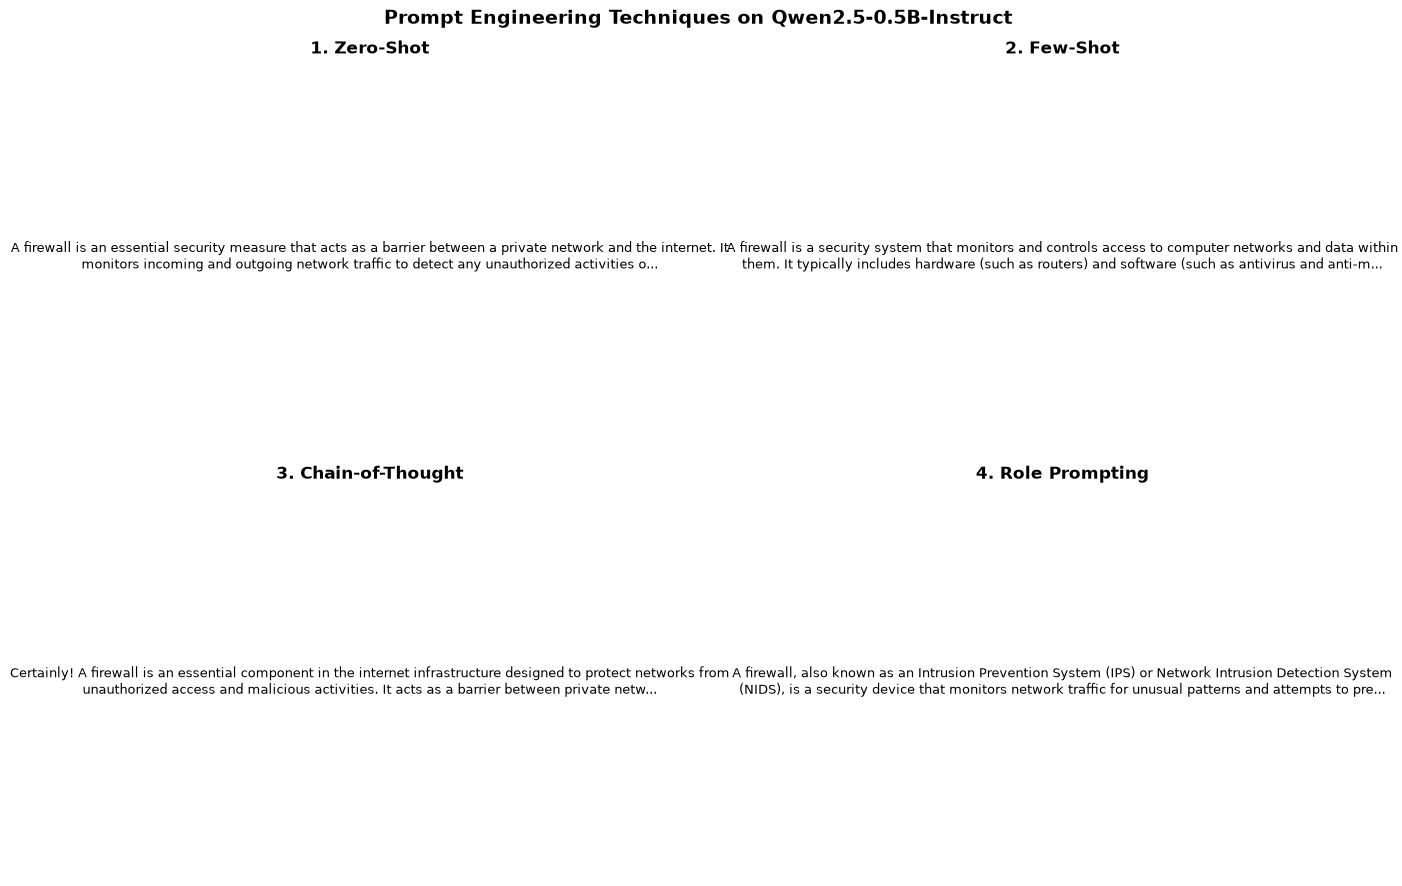

In [9]:
# Re-run all techniques and collect responses for visualization
techniques = []
responses = []

# Zero-Shot
techniques.append("1. Zero-Shot")
msg = [{"role": "user", "content": "What is a firewall?"}]
out = chat(msg, max_new_tokens=80, temperature=0.7)
responses.append(out[0]['generated_text'][-1]['content'])

# Few-Shot
techniques.append("2. Few-Shot")
msg = [
    {"role": "user", "content": "What is an IP address?"},
    {"role": "assistant", "content": "An IP address is a unique numerical label assigned to each device on a network."},
    {"role": "user", "content": "What is DNS?"},
    {"role": "assistant", "content": "DNS translates domain names into IP addresses."},
    {"role": "user", "content": "What is a firewall?"}
]
out = chat(msg, max_new_tokens=80, temperature=0.7)
responses.append(out[0]['generated_text'][-1]['content'])

# Chain-of-Thought
techniques.append("3. Chain-of-Thought")
msg = [{"role": "user", "content": "Explain what a firewall is. Think step by step."}]
out = chat(msg, max_new_tokens=120, temperature=0.7)
responses.append(out[0]['generated_text'][-1]['content'])

# Role Prompting
techniques.append("4. Role Prompting")
msg = [
    {"role": "system", "content": "You are a cybersecurity professor with 15 years of experience."},
    {"role": "user", "content": "What is a firewall?"}
]
out = chat(msg, max_new_tokens=100, temperature=0.7)
responses.append(out[0]['generated_text'][-1]['content'])

# Plot
plt.figure(figsize=(14, 9))
for i, (name, text) in enumerate(zip(techniques, responses)):
    plt.subplot(2, 2, i + 1)
    short = text[:200] + "..." if len(text) > 200 else text
    plt.text(0.5, 0.5, short, ha='center', va='center', wrap=True, fontsize=9)
    plt.title(name, fontsize=12, fontweight='bold')
    plt.axis('off')

plt.suptitle("Prompt Engineering Techniques on Qwen2.5-0.5B-Instruct", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()